# Cox-Time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn_pandas import DataFrameMapper
import torch
import torchtuples as tt

from pycox.models.cox_time import MLPVanillaCoxTime
from pycox.models import CoxTime
from pycox.evaluation import EvalSurv

In [2]:
SEED = 50

In [3]:
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## Dataset

In [4]:
from dataset_PropertyPrice import DatasetHousePrice

ds_name = 'house_price_traj'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_HousePrice'
SAVE_PATH = f'./pycox_models/more_g/{project}/cox_time_pycox_more_g_{SEED}'
g_resol = 0.01
t_resol = 1
split = 'train'
ds = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_train = ds._get_df_Xy_trans_obs_more_g()

split = 'test'
ds = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_test = ds._get_df_Xy_true_prob()

split = 'val'
ds = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_val = ds._get_df_Xy_trans_obs_more_g()

In [5]:
df_test

,traj_id,duration,g_max_by_time,event_observed,weight,feat__is_new_build,feat__long,feat__lat,feat__frac_properties_n_beds__1,feat__frac_properties_n_beds__2,...,feat__deprived_3_dim,feat__deprived_4_dim,feat__soc_grade_AB,feat__soc_grade_C1,feat__soc_grade_C2,feat__soc_grade_DE,feat__prop_type_Detached,feat__prop_type_SemiD,feat__prop_type_Terraced,is_t_trans
0,E06000001SemiNew,1,1.0,0.0,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
1,E06000001SemiNew,2,1.0,0.0,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
2,E06000001SemiNew,3,1.0,0.0,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
3,E06000001SemiNew,4,1.0,0.0,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
4,E06000001SemiNew,5,1.0,NaN,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,W06000024TerracedExisting,3,0.1,1.0,1,0.0,-1.530934,-0.521543,-0.507739,-0.313532,...,2.923401,1.212583,-1.515403,-1.384008,0.305800,2.075228,0.0,0.0,1.0,NaN
13996,W06000024TerracedExisting,4,0.1,1.0,1,0.0,-1.530934,-0.521543,-0.507739,-0.313532,...,2.923401,1.212583,-1.515403,-1.384008,0.305800,2.075228,0.0,0.0,1.0,NaN
13997,W06000024TerracedExisting,5,0.1,1.0,1,0.0,-1.530934,-0.521543,-0.507739,-0.313532,...,2.923401,1.212583,-1.515403,-1.384008,0.305800,2.075228,0.0,0.0,1.0,NaN
13998,W06000024TerracedExisting,6,0.1,1.0,1,0.0,-1.530934,-0.521543,-0.507739,-0.313532,...,2.923401,1.212583,-1.515403,-1.384008,0.305800,2.075228,0.0,0.0,1.0,NaN


In [6]:
df_train.head()

,traj_id,event_observed,duration,g_max_by_time,feat__is_new_build,feat__long,feat__lat,feat__frac_properties_n_beds__1,feat__frac_properties_n_beds__2,feat__frac_properties_n_beds__3,...,feat__deprived_4_dim,feat__soc_grade_AB,feat__soc_grade_C1,feat__soc_grade_C2,feat__soc_grade_DE,feat__prop_type_Detached,feat__prop_type_SemiD,feat__prop_type_Terraced,weight,is_t_trans
0,E06000001DetachedExisting,1,1.0,0.000580,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1
1,E06000001DetachedExisting,1,3.0,0.008855,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1
2,E06000001DetachedExisting,1,4.0,0.035069,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1
3,E06000001DetachedExisting,1,5.0,0.063205,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1
4,E06000001DetachedExisting,1,6.0,0.206230,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1


## Feature transforms

In [7]:
x_train = df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].astype('float32')
x_train['g_max_by_time'] = x_train['g_max_by_time']/ds.g_max
x_train = x_train.values

x_val = df_val.loc[:,df_val.columns.str.startswith('feat')|df_val.columns.str.startswith('g_max_by_time')].astype('float32')
x_val['g_max_by_time'] = x_val['g_max_by_time']/ds.g_max
x_val = x_val.values

x_test = df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].drop_duplicates().astype('float32')
x_test['g_max_by_time'] = x_test['g_max_by_time']/ds.g_max
x_test = x_test.values



In [8]:
df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].columns == (
    df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].columns
)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

We need no label transforms

In [9]:
get_target = lambda df: (df['duration'].astype('float32').values, df['event_observed'].astype('float32').values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = tt.tuplefy(x_val, y_val)

In [10]:
val.shapes()

((13945, 53), ((13945,), (13945,)))

With `TupleTree` (the results of `tt.tuplefy`) we can easily repeat the validation dataset multiple times. This will be useful for reduce the variance of the validation loss, as the validation loss of `CoxTime` is not deterministic.

In [11]:
val.repeat(2).cat().shapes()

((27890, 53), ((27890,), (27890,)))

## Neural net
 
We create a simple MLP with two hidden layers, ReLU activations, batch norm and dropout. 
The net required by `CoxTime` is slightly different than most of the other methods as it also take `time` and an additional input argument. 
We have therefore crated the `MLPVanillaCoxTime` class that is a suitable version of `tt.practical.MLPVanilla`.
This class also removes the options for setting `out_features` and `output_bias` as they should be `1` and `False`, respectively.
 
To see the code for the networks call `??MLPVanillaCoxTime`.

In [12]:
in_features = x_train.shape[1]
num_nodes = [64, 64, 64, 64]
batch_norm = False
dropout = 0

net = MLPVanillaCoxTime(in_features, num_nodes, batch_norm, dropout)

## Training the model

In [13]:
#model = CoxTime(net, tt.optim.Adam(lr=1e-2, weight_decay=1e-2))
model = CoxTime(net, tt.optim.Adam(lr=2e-3, weight_decay=2e-3))
# model = CoxTime(net, tt.optim.Adam(lr=1e-6, weight_decay=5e-3))

In [14]:
batch_size = 64

We include the `EarlyStopping` callback to stop training when the validation loss stops improving. After training, this callback will also load the best performing model in terms of validation loss.

In [15]:
epochs = 2000
callbacks = [tt.callbacks.EarlyStopping(patience=500)]
verbose = True

In [16]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val.repeat(10).cat())

0:	[0s / 0s],		train_loss: 0.4297,	val_loss: 0.2560
1:	[0s / 1s],		train_loss: 0.1907,	val_loss: 0.2238
2:	[0s / 1s],		train_loss: 0.1673,	val_loss: 0.2064
3:	[0s / 2s],		train_loss: 0.1539,	val_loss: 0.2073
4:	[0s / 2s],		train_loss: 0.1429,	val_loss: 0.1922
5:	[0s / 3s],		train_loss: 0.1289,	val_loss: 0.1763
6:	[0s / 3s],		train_loss: 0.1285,	val_loss: 0.1457
7:	[0s / 4s],		train_loss: 0.1247,	val_loss: 0.1677
8:	[0s / 4s],		train_loss: 0.1214,	val_loss: 0.1436
9:	[0s / 5s],		train_loss: 0.1179,	val_loss: 0.1666
10:	[0s / 5s],		train_loss: 0.1162,	val_loss: 0.1648
11:	[0s / 6s],		train_loss: 0.1160,	val_loss: 0.1669
12:	[0s / 7s],		train_loss: 0.1145,	val_loss: 0.1671
13:	[0s / 7s],		train_loss: 0.1126,	val_loss: 0.1651
14:	[0s / 8s],		train_loss: 0.1062,	val_loss: 0.1659
15:	[0s / 8s],		train_loss: 0.1135,	val_loss: 0.1457
16:	[0s / 9s],		train_loss: 0.1025,	val_loss: 0.2037
17:	[0s / 9s],		train_loss: 0.1011,	val_loss: 0.1444
18:	[0s / 10s],		train_loss: 0.1046,	val_loss: 0.1382
19

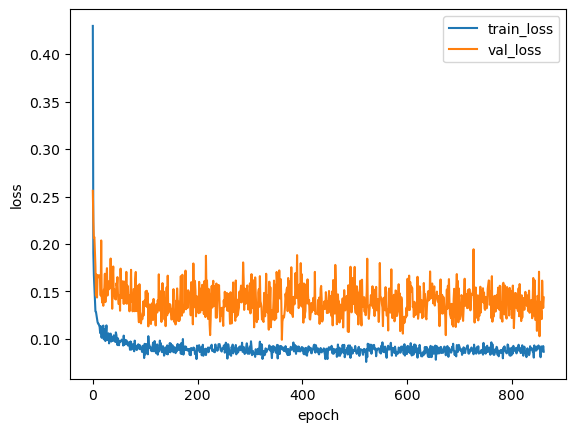

In [17]:
_ = log.plot()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.savefig(f'{SAVE_PATH}_training_curves.pdf')
log.to_pandas().to_csv(f'{SAVE_PATH}_training_curves.csv')

We can get the partial log-likelihood

In [18]:
model.partial_log_likelihood(*val).mean()

-7.087796

## Prediction

For evaluation we first need to obtain survival estimates for the test set.
This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

However, as `CoxCC` is semi-parametric, we first need to get the non-parametric baseline hazard estimates with `compute_baseline_hazards`. 

Note that for large datasets the `sample` argument can be used to estimate the baseline hazard on a subset.

In [19]:
_ = model.compute_baseline_hazards()

In [20]:
x_test.shape

(2000, 53)

In [21]:
x_test

array([[ 1.        ,  1.        ,  0.02188914, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.5       ,  1.        ,  0.02188914, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.33333334,  1.        ,  0.02188914, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.125     ,  0.        , -1.5309342 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.11111111,  0.        , -1.5309342 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.1       ,  0.        , -1.5309342 , ...,  0.        ,
         0.        ,  1.        ]], dtype=float32)

In [22]:
surv = model.predict_surv_df(x_test)

In [23]:
surv

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
duration,,,,,,,,,,,,,,,,,,,,,
1.0,0.999932,0.999824,0.998570,0.996289,0.992472,0.987673,0.982484,0.975466,0.967888,0.962305,...,0.999945,0.999941,0.999123,0.993799,0.981438,0.961671,0.938988,0.918841,0.898923,0.879756
2.0,0.999815,0.999251,0.994842,0.986814,0.975869,0.963729,0.948906,0.932392,0.915777,0.901638,...,0.999908,0.999827,0.994960,0.969068,0.924807,0.864416,0.798672,0.736391,0.677777,0.624240
3.0,0.999681,0.998138,0.987634,0.974447,0.957443,0.934535,0.908434,0.881079,0.854406,0.830972,...,0.999889,0.999478,0.980659,0.913996,0.803524,0.671739,0.544639,0.436244,0.347550,0.277268
4.0,0.999556,0.996364,0.980651,0.963002,0.937985,0.905389,0.868553,0.831177,0.795490,0.763972,...,0.999880,0.998055,0.952791,0.816024,0.611909,0.427350,0.295498,0.203420,0.140426,0.098000
5.0,0.999406,0.993013,0.972769,0.946662,0.910497,0.867228,0.817222,0.767953,0.721989,0.681612,...,0.999875,0.992219,0.883818,0.626143,0.371120,0.200299,0.106776,0.057120,0.031061,0.017348
6.0,0.999263,0.988705,0.960885,0.917875,0.862920,0.799648,0.730013,0.666227,0.613478,0.568395,...,0.999865,0.971678,0.691503,0.339195,0.118261,0.035556,0.010471,0.003151,0.000994,0.000334
7.0,0.999187,0.985568,0.948893,0.889368,0.814955,0.742344,0.666727,0.597982,0.542006,0.495053,...,0.999853,0.931490,0.497176,0.153200,0.026997,0.003811,0.000521,0.000074,0.000012,0.000002


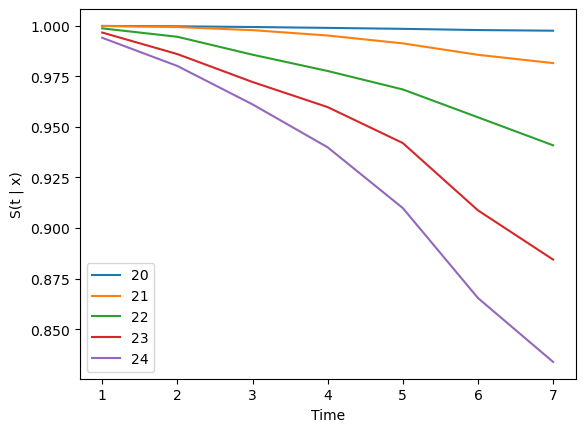

In [24]:
n = 5
surv.iloc[:, 5*(n-1):5*n].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

In [25]:
model.save_net(SAVE_PATH)